In [1]:
import gdown

gdown.download(r'https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

Downloading...
From: https://bit.ly/3pK7iuu
To: c:\data\ns_book7.csv
100%|██████████| 53.8M/53.8M [00:06<00:00, 8.49MB/s]


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [ ]:
import numpy as np
from scipy import stats

S = ns_book7['대출건수']
m = np.mean(S)
s = np.std(S)
z = (S.sample(n=1)-m)/s
print(z)

stats.zscore(S)
stats.norm.cdf(-0.393863)

print(stats.norm.cdf(1.5) - stats.norm.cdf(-1.5))

stats.norm.ppf(0.99)
stats.norm.cdf(2) - stats.norm.cdf(-2)

17378   -0.445732
Name: 대출건수, dtype: float64
0.8663855974622838


np.float64(0.9544997361036416)

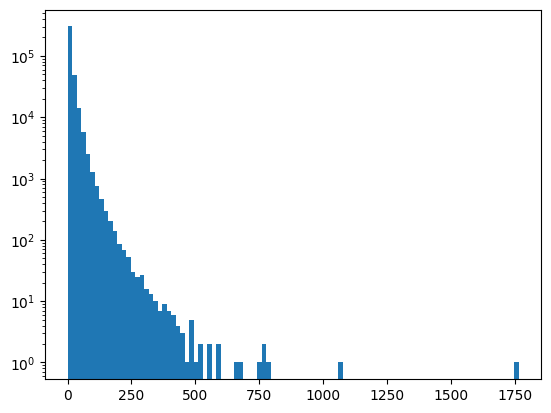

In [32]:
import matplotlib.pyplot as plt

plt.hist(ns_book7['대출건수'], bins=100)
plt.yscale('log')
plt.show()

sample_dist = []
for _ in range(1000):
    x = ns_book7['대출건수'].sample(30).mean()
    sample_dist.append(x)


In [45]:
print("모평균:%0.3f"%np.mean(ns_book7['대출건수']), "표본평균:%0.3f"%np.mean(sample_dist))
print('모표준편차:%1.3f'%np.std(ns_book7['대출건수']/np.sqrt(30)), '표본표준편차"%1.3f'%np.std(sample_dist))


모평균:11.593 표본평균:11.626
모표준편차:3.520 표본표준편차"3.523


In [ ]:
py_books_idx = ns_book7['주제분류번호'].astype('string').str.strip().str.startswith('00', na=False) & \
    ns_book7['도서명'].astype('string').str.strip().str.contains(r'(python|파이썬|파이톤|파이선)', regex=True, case=False, na=False)
py_books = ns_book7[py_books_idx]



C:\Users\박중현\AppData\Local\Temp\ipykernel_9328\1668169430.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ns_book7['도서명'].astype('string').str.strip().str.contains(r'(python|파이썬|파이톤|파이선)', regex=True, case=False, na=False)


12.951216137652683 16.014301103726627


In [14]:
import sqlite3

conn = sqlite3.connect('bookinfo.db')
c = conn.cursor()
c.execute("CREATE TABLE IF NOT EXISTS bookinfo_book (도서명 TEXT, 저자 TEXT, 대출건수 INTEGER)")
#c.execute("DROP TABLE bookinfo_book")
c.close()
conn.commit()
conn.close()



Downloading...
From: https://bit.ly/3RhoNho
To: c:\data\ns_202104.csv
100%|██████████| 57.6M/57.6M [00:05<00:00, 11.4MB/s]


'ns_202104.csv'

In [19]:
import gdown
gdown.download(r'https://bit.ly/3RhoNho', 'ns_202104.csv', quiet=False)
import sqlite3
import pandas as pd
ns_df = pd.read_csv('ns_202104.csv', encoding='utf-8', low_memory=False)

conn = sqlite3.connect('bookinfo.db')
c = conn.cursor()
c.execute("CREATE TABLE IF NOT EXISTS bookinfo_table (도서명 TEXT, 저자 TEXT, 대출건수 INTEGER)")

for idx, row in ns_df.iterrows():
    c.execute("INSERT INTO bookinfo_table (도서명, 저자, 대출건수) VALUES(?, ?, ?)", (row['도서명'], row['저자'], row['대출건수']))


Downloading...
From: https://bit.ly/3RhoNho
To: c:\data\ns_202104.csv
100%|██████████| 57.6M/57.6M [00:04<00:00, 12.5MB/s]


In [21]:
ns_df[['도서명', '저자', '대출건수']].to_sql('bookinfo_table', conn, if_exists='replace', index=False)

401682

In [ ]:
bookinfo_df = pd.read_sql_query("SELECT * FROM bookinfo_table", conn)

,도서명,저자,대출건수
0,인공지능과 흙,김동훈 지음,0
1,가짜 행복 권하는 사회,김태형 지음,0
2,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,0
3,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",0
4,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,0


In [38]:
import numpy as np

c.execute("SELECT COUNT(*) FROM bookinfo_table")
c.fetchone()

c.execute("SELECT SUM(대출건수) FROM bookinfo_table")
c.fetchone()

c.execute("SELECT AVG(대출건수) FROM bookinfo_table")
c.fetchall()

c.execute("SELECT 도서명, 대출건수 FROM bookinfo_table ORDER BY 대출건수 DESC")
c.fetchmany(10)

conn.commit()
c.close()
conn.close()